# Estimating $\pi$ with Monte Carlo

Here's one of my favorite "the answer falls out of randomness" tricks. Take the
unit square $[0,1]^2$ and the quarter circle $x^2 + y^2 \le 1$ inside it. The
quarter circle has area $\tfrac{\pi}{4}$, the square has area $1$, so a uniformly
random point lands inside the circle with probability

$$
P(\text{inside}) = \frac{\text{area of quarter circle}}{\text{area of square}} = \frac{\pi}{4}.
$$

So if we sample $N$ random points and $k$ land inside, then $k/N \approx \pi/4$,
which means $\pi \approx 4k/N$. Let's watch it work.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

rng = np.random.default_rng(0)
N = 5000
pts = rng.random((N, 2))
inside = (pts[:, 0] ** 2 + pts[:, 1] ** 2) <= 1.0

pi_estimate = 4 * inside.mean()
print(f"Points sampled: {N}")
print(f"Estimate of pi: {pi_estimate:.5f}")
print(f"True pi:        {np.pi:.5f}")

Points sampled: 5000
Estimate of pi: 3.17280
True pi:        3.14159


## Visualizing the darts

Each point is colored by whether it landed inside the quarter circle. The ratio
of blue to total points, times four, is our estimate.

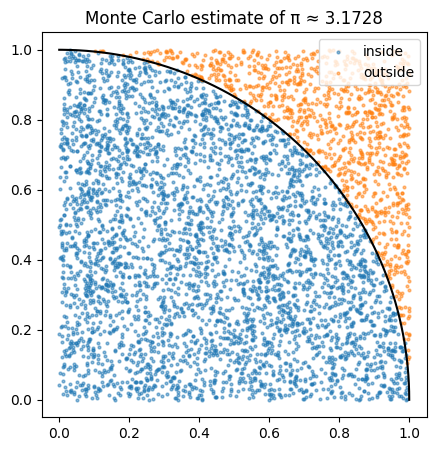

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(pts[inside, 0], pts[inside, 1], s=4, alpha=0.5, label="inside")
ax.scatter(pts[~inside, 0], pts[~inside, 1], s=4, alpha=0.5, label="outside")
theta = np.linspace(0, np.pi / 2, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black", linewidth=1.5)
ax.set_aspect("equal")
ax.set_title(f"Monte Carlo estimate of \u03c0 \u2248 {pi_estimate:.4f}")
ax.legend(loc="upper right")
plt.show()

## Convergence

The estimate gets better as $N$ grows — the error shrinks like $1/\sqrt{N}$,
the usual Monte Carlo rate. Here's a quick table.

In [3]:
sizes = [100, 1000, 10000, 100000]
rows = []
for n in sizes:
    p = rng.random((n, 2))
    est = 4 * ((p[:, 0] ** 2 + p[:, 1] ** 2) <= 1.0).mean()
    rows.append({"N": n, "estimate": round(est, 5), "abs_error": round(abs(est - np.pi), 5)})

df = pd.DataFrame(rows)
df

,N,estimate,abs_error
0,100,3.08000,0.06159
1,1000,3.12400,0.01759
2,10000,3.15360,0.01201
3,100000,3.14212,0.00053
